# Notebook 1: Fock States, Photon Number States

## What are we exploring?

**Fock states** $|n\rangle$ are the most fundamental quantum states of light.
They are eigenstates of the photon number operator $\hat{n} = \hat{a}^\dagger\hat{a}$,
meaning they contain *exactly* $n$ photons with zero uncertainty ($\Delta n = 0$).

The Fock states form a complete orthonormal basis for the single-mode Hilbert space:
$$\langle m | n \rangle = \delta_{mn}, \quad \sum_{n=0}^{\infty} |n\rangle\langle n| = \hat{I}$$

Any quantum state of light can be expanded in this basis:
$|\psi\rangle = \sum_n c_n |n\rangle$.

## Why Fock states matter

Fock states are **non-classical**; no classical electromagnetic wave has a definite
photon number. In a classical wave, the intensity and photon number fluctuate. The
key signatures of non-classicality are:
- **Anti-bunching**: $g^{(2)}(0) < 1$ (photons prefer to arrive alone)
- **Wigner negativity**: The Wigner function $W(x,p)$ has negative regions

## Operator-basis note

Photon number $n$ is a discrete basis label for the harmonic-oscillator Hilbert
space. The useful structure here is the operator-eigenstate relationship
$\hat{n}|n\rangle=n|n\rangle$ and the expansion of arbitrary single-mode states in
the number basis.

## Conventions used in this notebook

- Natural units are used for the oscillator algebra: $\hbar=1$.
- `N` is the Hilbert-space dimension, so photon numbers run from `0` to `N-1`.
- Quadratures use $X=(a+a^\dagger)/\sqrt{2}$ and $P=(a-a^\dagger)/(i\sqrt{2})$.
- Wigner plots use the same X,P axes and must integrate to approximately 1 on the plotted grid.


## Setup: Imports and Hilbert Space Configuration

In [1]:
from pathlib import Path
import sys
import math
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import qutip

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
from qo_utils import (
    photon_distribution,
    plot_photon_distribution,
    plot_wigner,
    wigner_normalization,
    mean_photon_number,
    photon_variance,
    compute_g2_zero,
    mandel_Q,
    coherent_tail,
    cutoff_from_tail,
)

# Set plot style
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'figure.figsize': (8, 5),
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'text.usetex': False,
    'mathtext.fontset': 'stix',
    'font.family': 'STIXGeneral',
})

# For this notebook, we use N=20 (sufficient for Fock states |0> through |10>)
N = 20
a = qutip.destroy(N)
n_op = a.dag() * a  # Number operator

print(f"Hilbert space dimension: N = {N}")
print(f"Working with Fock states |0> through |{N-1}>")

Hilbert space dimension: N = 20
Working with Fock states |0> through |19>


## Creating Fock States

We create Fock states $|n\rangle$ using `qutip.basis(N, n)`, where $N$ is the
truncation dimension and $n$ is the photon number. Let's create and examine
several Fock states.

In [2]:
# Create Fock states |0> through |5>
fock_states = {n: qutip.basis(N, n) for n in range(6)}

# Verify properties
print("=== Fock State Properties ===\n")
for n, state in fock_states.items():
    mn = mean_photon_number(state, a)
    var_n = photon_variance(state, a)
    print(f"|{n}>: <n> = {mn:.1f}, Dn^2 = {var_n:.2e}, "
          f"||psi|| = {state.norm():.6f}")

=== Fock State Properties ===

|0>: <n> = 0.0, Dn^2 = 0.00e+00, ||psi|| = 1.000000
|1>: <n> = 1.0, Dn^2 = 0.00e+00, ||psi|| = 1.000000
|2>: <n> = 2.0, Dn^2 = 0.00e+00, ||psi|| = 1.000000
|3>: <n> = 3.0, Dn^2 = 0.00e+00, ||psi|| = 1.000000
|4>: <n> = 4.0, Dn^2 = 0.00e+00, ||psi|| = 1.000000
|5>: <n> = 5.0, Dn^2 = 3.55e-15, ||psi|| = 1.000000


As expected, each Fock state has exactly $n$ photons with zero variance.
The norm is 1.0 for all states, confirming proper normalization.

## Photon Number Distributions

For a Fock state $|n\rangle$, the photon number distribution is a delta function:
$$P(m) = |\langle m | n \rangle|^2 = \delta_{mn}$$

Let's plot $P(m)$ for $|0\rangle$, $|1\rangle$, $|3\rangle$, and $|5\rangle$.

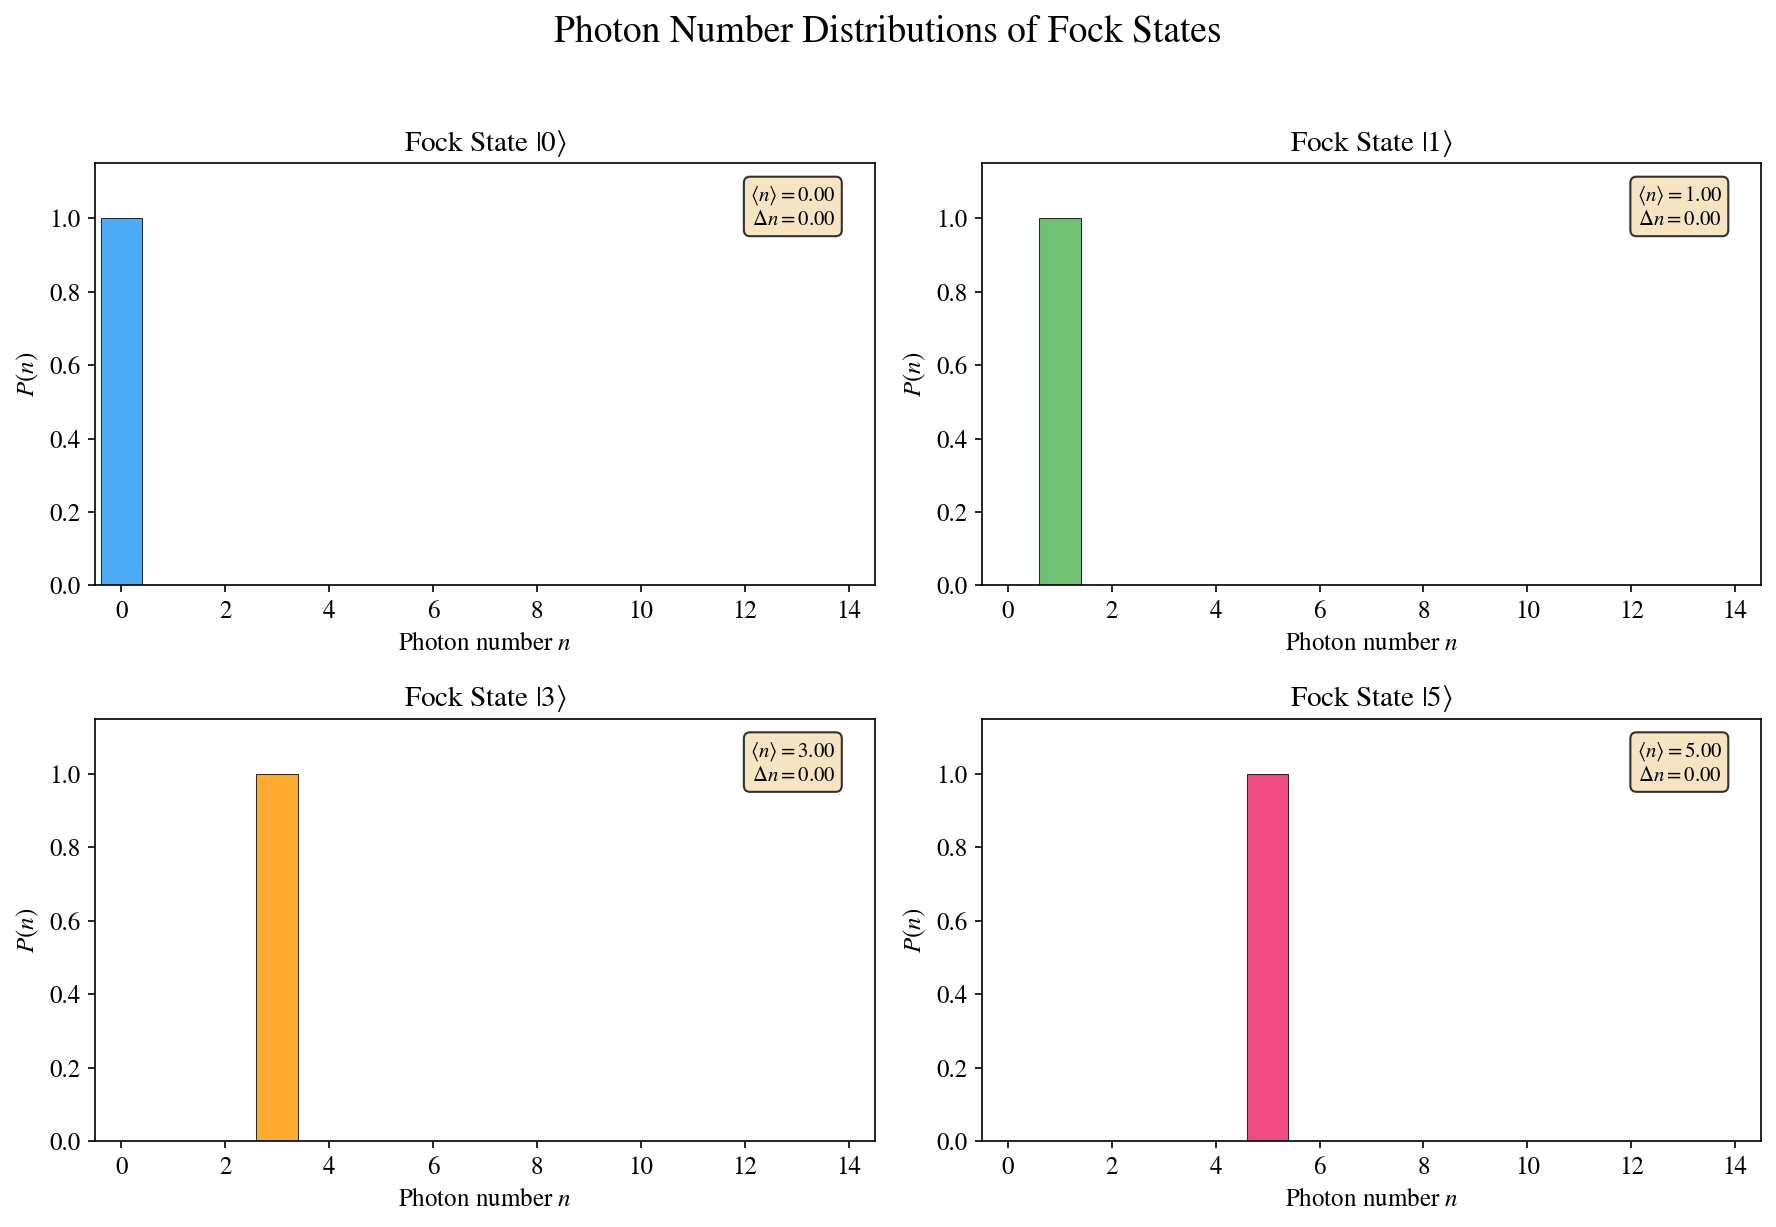

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
states_to_plot = [0, 1, 3, 5]
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

for idx, (n_val, color) in enumerate(zip(states_to_plot, colors)):
    ax = axes[idx // 2, idx % 2]
    state = fock_states[n_val]
    plot_photon_distribution(state, n_max=15,
                             title=rf'Fock State $|{n_val}\rangle$',
                             ax=ax, color=color, show_stats=True)

plt.suptitle('Photon Number Distributions of Fock States', fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fock_photon_distributions.png', bbox_inches='tight', dpi=300)
plt.savefig(FIG_DIR / 'fock_photon_distributions.svg', bbox_inches='tight')
plt.show()

Each distribution shows a single bar at the photon number $n$, confirming that
Fock states have a delta-function photon number distribution. The annotations
show $\langle n \rangle = n$ and $\Delta n = 0$ as expected.

## Second-Order Coherence: $g^{(2)}(0)$

The second-order coherence function at zero time delay classifies quantum light:

$$g^{(2)}(0) = \frac{\langle \hat{a}^\dagger \hat{a}^\dagger \hat{a} \hat{a} \rangle}
{\langle \hat{a}^\dagger \hat{a} \rangle^2} = 1 - \frac{1}{n} \quad
\text{for Fock state } |n\rangle$$

For $|1\rangle$: $g^{(2)}(0) = 0$, **perfect anti-bunching**.
Two photons can NEVER be detected simultaneously.

In [4]:
print("=== g^(2)(0) for Fock States ===\n")
print(f"{'State':>10} {'g2(0) computed':>15} {'g2(0) theory':>15} {'Match?':>8}")
print("-" * 52)

for n_val in range(1, 11):
    state = qutip.basis(N, n_val)
    g2_computed = compute_g2_zero(state, a)
    g2_theory = 1 - 1/n_val
    match = "YES" if np.isclose(g2_computed, g2_theory, atol=1e-10) else "NO"
    print(f"|{n_val}>{' ':>6} {g2_computed:>15.6f} {g2_theory:>15.6f} {match:>8}")

# Also check vacuum
g2_vac = compute_g2_zero(qutip.basis(N, 0), a)
print(f"\n|0> (vacuum): g^(2)(0) = {g2_vac} (undefined -- division by zero)")

=== g^(2)(0) for Fock States ===

     State  g2(0) computed    g2(0) theory   Match?
----------------------------------------------------
|1>              0.000000        0.000000      YES
|2>              0.500000        0.500000      YES
|3>              0.666667        0.666667      YES
|4>              0.750000        0.750000      YES
|5>              0.800000        0.800000      YES
|6>              0.833333        0.833333      YES
|7>              0.857143        0.857143      YES
|8>              0.875000        0.875000      YES
|9>              0.888889        0.888889      YES
|10>              0.900000        0.900000      YES

|0> (vacuum): g^(2)(0) = nan (undefined -- division by zero)


All computed $g^{(2)}(0)$ values match the theoretical formula $1 - 1/n$
to numerical precision. Key observations:
- $g^{(2)}(0) = 0$ for $|1\rangle$: **perfect anti-bunching**
- $g^{(2)}(0) \to 1$ as $n \to \infty$: approaches Poissonian (coherent) limit
- $g^{(2)}(0)$ is undefined for the vacuum $|0\rangle$ ($\langle n \rangle = 0$)

## Wigner Functions: Phase-Space Portraits

The Wigner function $W(x, p)$ is a quasi-probability distribution in phase space.
For Fock states, the Wigner function reveals **non-classicality** through
negative regions:
- $|0\rangle$: Positive Gaussian (minimum uncertainty, circular)
- $|1\rangle$: Ring with **negative center**, first sign of non-classicality!
- $|n\rangle$: $n+1$ concentric rings with alternating positive/negative values